# StreamFlix Content Analytics - Phase 2: Exploratory Data Analysis (EDA) with Charts

### **Analyst**: Eram Aiysha Shaikh
### **Start Date**:10/07/2026               **End Date**:15/07/2026

**Objective**: Build the 10 required charts covering viewing trends, content 
performance, subscriber behavior, and audience experience. Each chart is preceded by 
a short note on why that chart answers a real business question, and followed by a 
written observation - not just a description of the chart, but what it means for 
StreamFlix.

### step 1: Load all the libraries and then read the 6 CSV files

In [3]:
#import the required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

#Load the datasets
DATA_DIR = "../data/"
subscribers = pd.read_csv('../data/subscribers.csv')
titles = pd.read_csv('../data/titles.csv')
watch_history = pd.read_csv('../data/watch_history.csv')
ratings = pd.read_csv('../data/ratings.csv')
reviews = pd.read_csv('../data/reviews.csv')
watchlist = pd.read_csv('../data/watchlist.csv')

### step 2: Convert the date columns to proper datetime datatype

In [ ]:
#Converting all the date columns to proper datetime datatype
subscribers['signup_date']=pd.to_datetime(subscribers['signup_date'])#this line convert the date object to datatime datatype
subscribers['churn_date']=pd.to_datetime(subscribers['churn_date'])

ratings['rating_date']=pd.to_datetime(ratings['rating_date'])

reviews['review_date']=pd.to_datetime(reviews['review_date'])

watch_history['watch_date']=pd.to_datetime(watch_history['watch_date'])

watchlist['added_date']=pd.to_datetime(watchlist['added_date'])

titles['license_expiry'] = pd.to_datetime(titles['license_expiry'])

print("added_date:", watchlist['added_date'].dtype)
print("churn_date:", subscribers['churn_date'].dtype)
print("rating_date:", ratings['rating_date'].dtype)
print("review_date:", reviews['review_date'].dtype)
print("license_expiry:", titles['license_expiry'].dtype)
print("signup_date:", subscribers['signup_date'].dtype)
print("watch_date:", watch_history['watch_date'].dtype)

print(watch_history.shape[0], 'watch sessions across', subscribers.shape[0], 'subscribers')

added_date: datetime64[us]
churn_date: datetime64[us]
rating_date: datetime64[us]
review_date: datetime64[us]
license_expiry: datetime64[us]
signup_date: datetime64[us]
watch_date: datetime64[us]
650000 watch sessions across 15000 subscribers


## Chart 1 - Monthly viewing volume

**Why this chart first:** before looking at *what* people watch, it's worth seeing 
*how much* activity is happening over time. This is the natural starting point for 
any EDA - it immediately shows growth, decline, seasonality, or gaps worth 
investigating before going deeper.

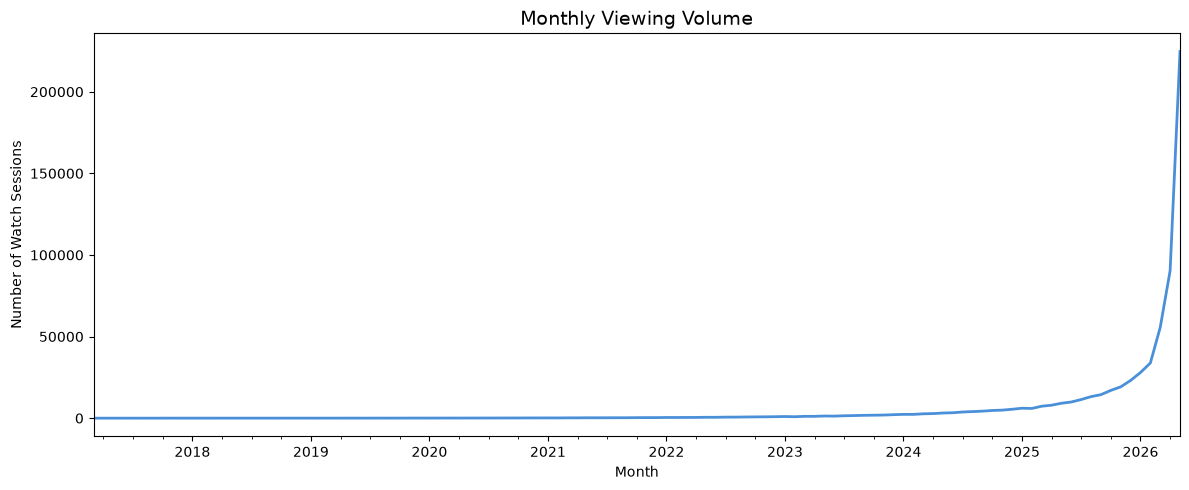

In [5]:
#Now this chart requires number of sessions per month, so some filtering needs to be done first
#So we have the whole date but we want according to the month we will group the data by month and check the size to see how many total sessions are there
watch_activity = watch_history.set_index('watch_date')#set the index to watch_date
watch_activity = watch_activity.resample('ME')#resample works on datetime and it has grouped by month 'ME' i.e month end, since it works on datetime that is why I have set the index tp watch_date 
watch_activity = watch_activity.size()#calculation the total records in each month, here we are not using count() because count checks only non null values and it will not count the months where the data is null

plt.figure(figsize=(12, 5))
watch_activity.plot(kind='line', color='#4A90D9', linewidth=2)#using line chart to see the trends over month
plt.title('Monthly Viewing Volume', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Watch Sessions')
plt.tight_layout()
plt.savefig('../reports/chart1_monthly_viewing_volume.png', dpi=150)#saving the chart in reports folder
plt.show()


**Observation:** Viewing volume shows sustained, accelerating growth across the 
platform's full history - from a handful of sessions per month in 2017 to over 
220,000 sessions in the most recent month (May 2026). The growth curve is not linear; 
it steepens sharply from around 2023 onward, suggesting either strong subscriber 
acquisition in recent years or a genuine platform-wide engagement increase.

## Chart 2 - Monthly watch hours trend 




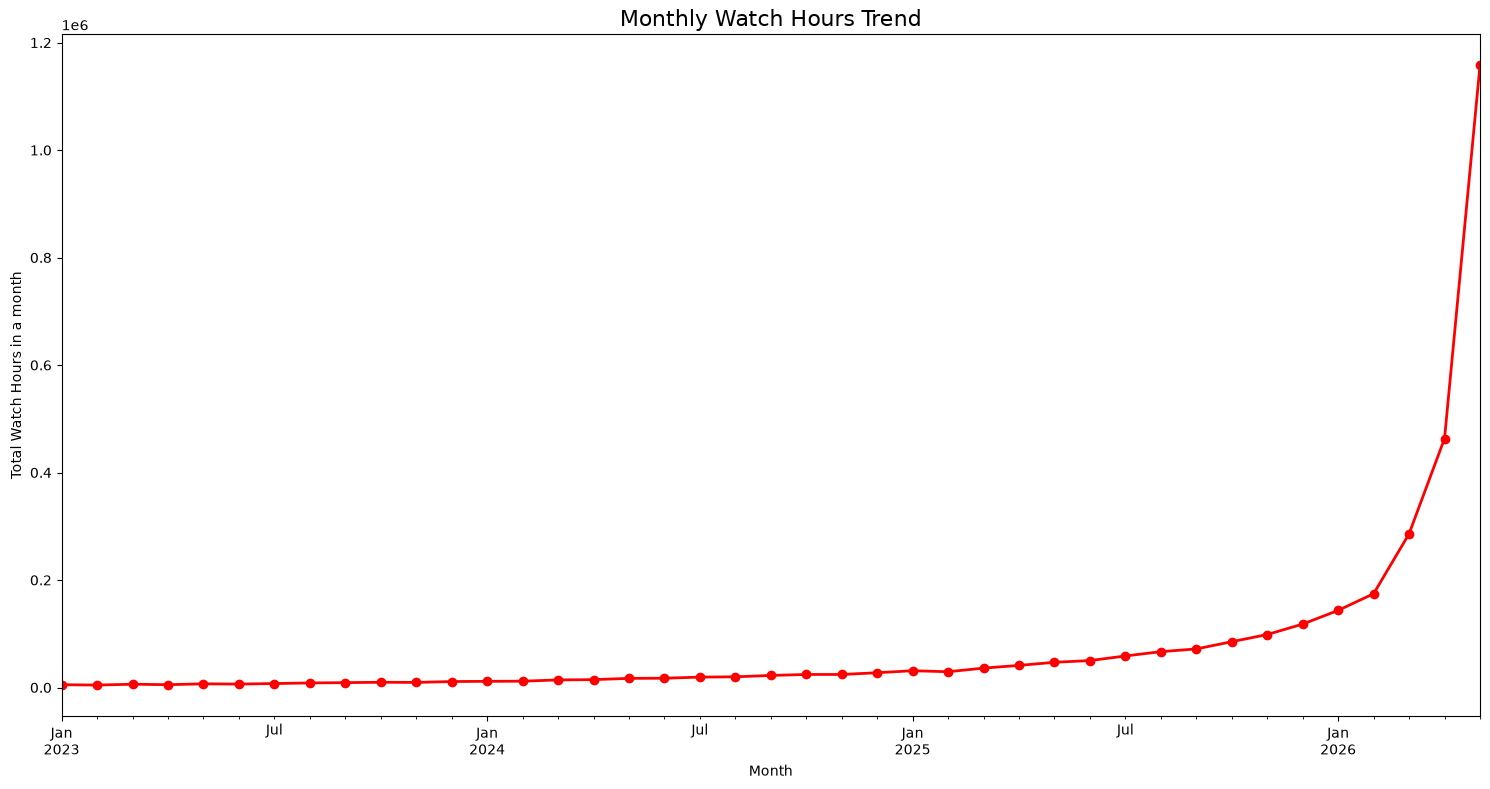

In [ ]:
watch_hour_trend = watch_history.set_index('watch_date')#Make the date the main organizer because resample() needs a datetime index.
watch_hour_trend = watch_hour_trend.resample('ME')#Group all records month-wise (ME = Month End).
watch_hour_trend = watch_hour_trend['watch_duration_min'].sum()/60#Add all watch minutes in each month and convert them into hours.

recent_watch_hours = watch_hour_trend[watch_hour_trend.index >= '2023-01-01']#isolate the last 3 full years for a clearer YoY read

'''plt.Figure(figsize=(25,8))
recent_watch_hours.plot(kind='line', color='red', linewidth=2, marker='o', markersize=3)#using line chart to see the trends over month)
plt.title('Monthly Watch Hours Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Watch Hours in a month')
#plt.tight_layout()
#plt.savefig('../reports/chart2_monthly_watch_hours_trend.png', dpi=150)#saving the chart in reports folder
plt.show()'''

fig, ax = plt.subplots(figsize=(15, 8))

recent_watch_hours.plot(
    ax=ax,
    kind='line',
    color='red',
    marker='o',
    linewidth=2
)

ax.set_title("Monthly Watch Hours Trend", fontsize=16)
ax.set_xlabel("Month")
ax.set_ylabel("Total Watch Hours in a month")

plt.tight_layout()
plt.savefig('../reports/chart2_monthly_watch_hours_trend.png', dpi=150)#saving the chart in reports folder
plt.show()

**Observation:** Watch hours grew from roughly 15,000 hours/month in early 2023 to 
over 1.1 million hours in May 2026 - a compounding, not flat, growth pattern. Each 
year's peak substantially exceeds the previous year's, which is a healthy sign for a 
subscription business, but the very steep final few months (March-May 2026) is worth 
treating cautiously: it could reflect real momentum, or could partly be an artifact 
of the dataset's generation window ending mid-2026 with incomplete cooling-off. This 
is a good candidate to sanity-check against the actual subscriber signup trend before 
presenting it as pure organic growth.

## Chart 3 - Genre-wise watch-hours share 

Why genre-wise:
* To know which genre the subscriber like most to watch is the basic idea behind genre wise watch hours.
* Since the genre column is in titles table and all the watch related history is in the watch_history table that is why first we need to merge the two to collect the data required to visualize this.
* After the two, grouped them on the basis of primary_genre to get the watch hours of each genre.
* This is used to make the contect investment decision.
* content investment decisions (which genres to commission, license, 
or retire) should follow where the audience's actual time goes, not just where the 
catalogue's title count is concentrated.

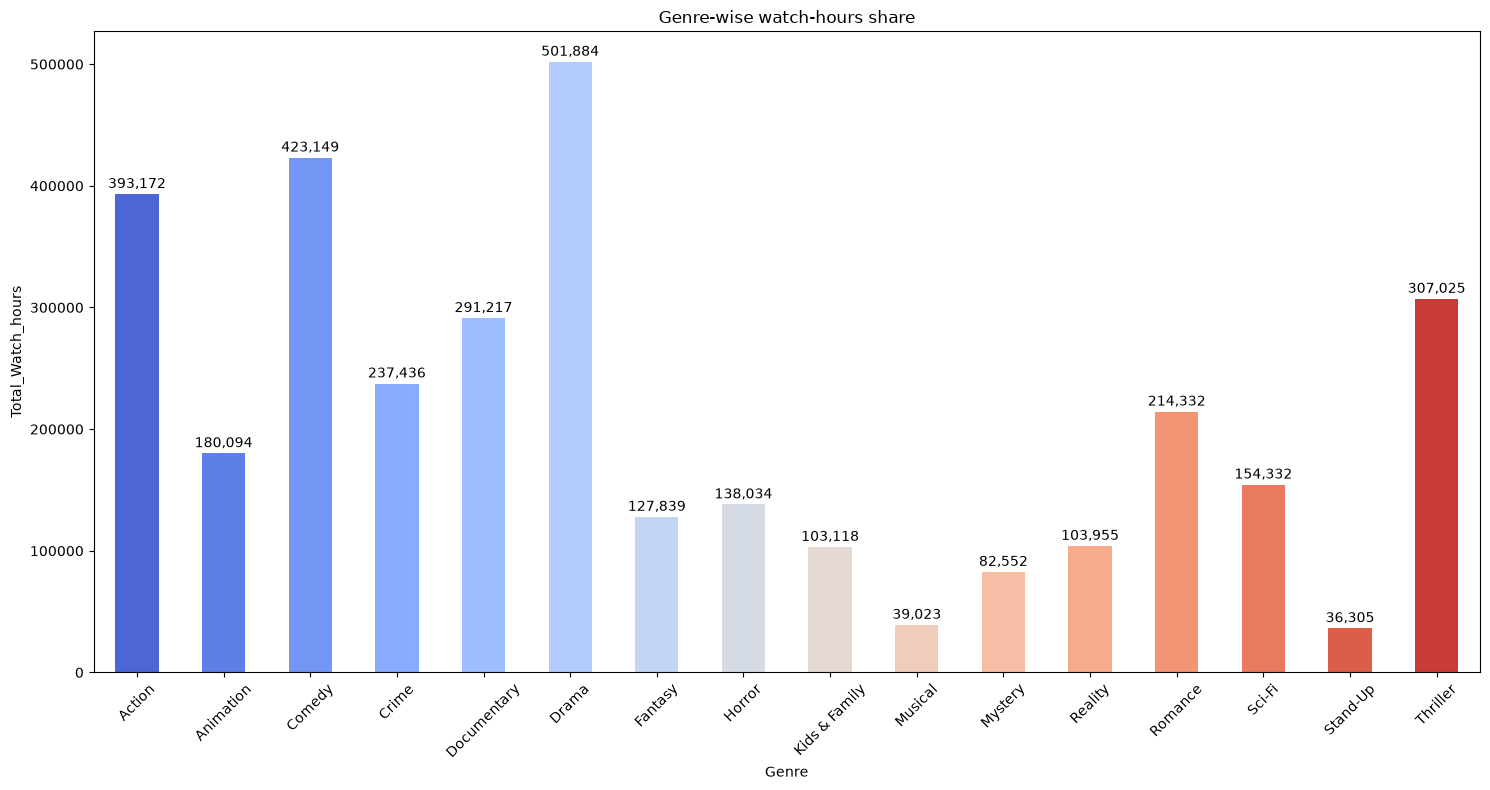

primary_genre
Action           393171.916667
Animation        180093.938333
Comedy           423149.053333
Crime            237435.838333
Documentary      291216.898333
Drama            501884.466667
Fantasy          127838.850000
Horror           138033.605000
Kids & Family    103118.066667
Musical           39023.391667
Mystery           82552.373333
Reality          103954.906667
Romance          214332.301667
Sci-Fi           154332.208333
Stand-Up          36305.255000
Thriller         307024.663333
Name: watch_duration_min, dtype: float64


In [ ]:
collected_data = watch_history.merge(titles[['title_id','primary_genre','type']],
                                     on='title_id',
                                     how='left')#watch_history left merged with titles on title_id to get the genre 
genre_wise_watch_hours = collected_data.groupby('primary_genre')['watch_duration_min'].sum()/60#since i want genre wise watch hours,it is grouped by genre then sumed up to get the total duration and then divided by 60 to get in hours

fig, ax = plt.subplots(figsize=(15,8))

colors = sns.color_palette('coolwarm', n_colors=len(genre_wise_watch_hours))#select the colors
genre_wise_watch_hours.plot(ax=ax, kind='bar', color=colors)#plot a bar chart
ax.tick_params(axis='x', rotation=45)

plt.title('Genre-wise watch-hours share')
plt.xlabel('Genre')
plt.ylabel('Total_Watch_hours')
for i, v in enumerate(genre_wise_watch_hours.values): #label the values on top of each bar
    ax.text(
        i,
        v + (genre_wise_watch_hours.max() * 0.01),
        f'{v:,.0f}',
        ha='center'
    )
plt.tight_layout()
plt.savefig('../reports/chart3_genre_wise_watch_hours.png', dpi=150)#saving the chart in reports folder
plt.show()

print(genre_wise_watch_hours)

**Observation:** Drama leads with roughly 502,000 watch hours, 
followed closely by Comedy (~423,000) and Action (~393,000) - together these three 
genres account for over 40% of all viewing time. At the other end, Musical and 
Stand-Up comedy trail far behind at under 40,000 hours each, under 1.5% of total 
viewing. This is a strong signal for content strategy: Drama/Comedy/Action are the 
genres to prioritize for new licensing and Originals investment, while Musical and 
Stand-Up may need a harder look at whether their catalogue size justifies their 
licensing cost.

## Chart 4 - Content type split 

Why Content type split :
* To know which content type is hyped among the audience.
* Since there are only two content types i.e TV and Movies, we can just take out the value counts and make a donut chart of it to visualize.
* This is used because movies and TV shows drive very different engagement patterns 
(one-off viewing vs. repeat/binge viewing), and the split affects everything from 
content acquisition budget to how "engagement" should even be measured.



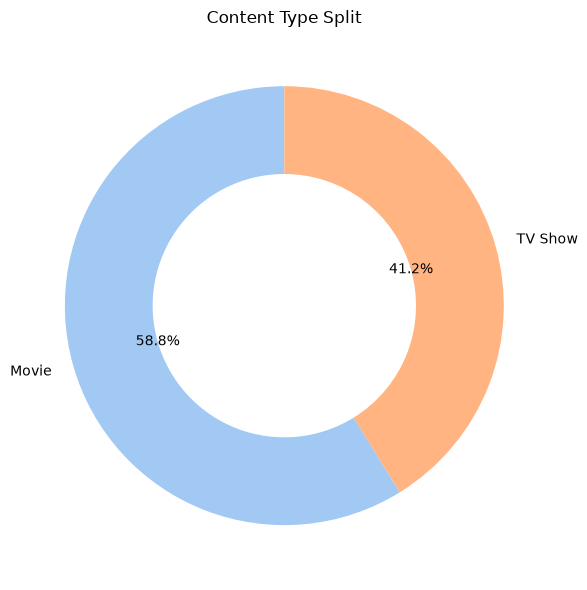

type
Movie      382330
TV Show    267670
Name: count, dtype: int64


In [ ]:
#This is thecontent type split i.e to show count of TV and Movies not the watch hours of TV and Movies
content_type_split = collected_data['type'].value_counts()#since i have already merged watch_history and titles tables, it has the type col has well whose valu counts will give the proper evaluation

fig, ax = plt.subplots(figsize=(8,6))

colors = sns.color_palette('pastel', len(content_type_split))

ax.pie(                                 #plot a donut chart
    content_type_split,
    labels=content_type_split.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width':0.4}   # Makes it a donut
)
ax.set_title('Content Type Split')
plt.tight_layout()
fig.savefig('../reports/chart4a_content_type_split.png', dpi=150)  # saving the chart in reports folder
plt.show()

print(content_type_split)

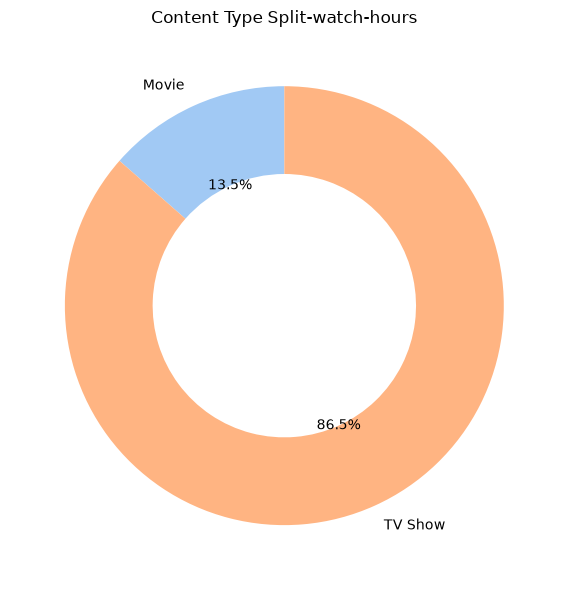

type
Movie      4.508588e+05
TV Show    2.882609e+06
Name: watch_duration_min, dtype: float64


In [ ]:
#this is the watch hours based on type
content_type_watch_hours = collected_data.groupby('type')['watch_duration_min'].sum()/60#Add all watch minutes in each type and convert them into hours.

fig,ax = plt.subplots(figsize=(8,6))

colors = sns.color_palette('pastel',len(content_type_watch_hours))

ax.pie(
    content_type_watch_hours,
    labels=content_type_watch_hours.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'width':0.4}   # Makes it a donut
)
ax.set_title('Content Type Split-watch-hours')
plt.tight_layout()
fig.savefig('../reports/chart4b_content_type_split.png', dpi=150)  # saving the chart in reports folder
plt.show()

print(content_type_watch_hours)

**Observation:** 
Chart 4A shows that Movies account for 382,330 watch sessions (58.8%), while TV Shows account for 267,670 watch sessions (41.2%). This indicates that users start watching Movies more frequently than TV Shows.

However, Chart 4B tells a different story. Although Movies have more watch sessions, TV Shows contribute approximately 2.88 million watch hours (86.5%), compared to only 0.45 million watch hours (13.5%) for Movies.

This suggests that TV Shows generate significantly higher watch time despite having fewer watch sessions. A likely reason is that TV Shows consist of multiple episodes, encouraging users to watch for longer durations or binge-watch entire series, whereas Movies are typically single, standalone pieces of content.

The comparison highlights an important business insight: watch session count alone does not accurately represent user engagement. While Movies attract more viewing sessions, TV Shows are far more effective at retaining viewers and driving total watch time, making them a valuable content category for increasing platform engagement and user retention.

|   A   |   B   |
|---|---|
| **Content Type Split** | **Content Type Watch Hours** |
| Split based on the **count** of each content type | Split based on the **total watch hours** of each content type |
|   Chart 4A   |   Chart 4B   |
|   Movie      382330(58.8%)  |  Movie      4.508588e+05(13.5%)  |
|   TV Show    267670(41.2%)  |  TV Show   2.882609e+06(86.5%)  |

## Chart 5 - Top 10 countries by watch hours 

Why top 10 countries watch hours :
* Top 10 countries whose audience love streamflix.
* Top 10 countries contributing to the actual engagement watch duration
* This is used to identify the biggest markets by actual engagement (not just 
subscriber count) tells StreamFlix where to prioritize localized content, marketing 
spend, and infrastructure investment.


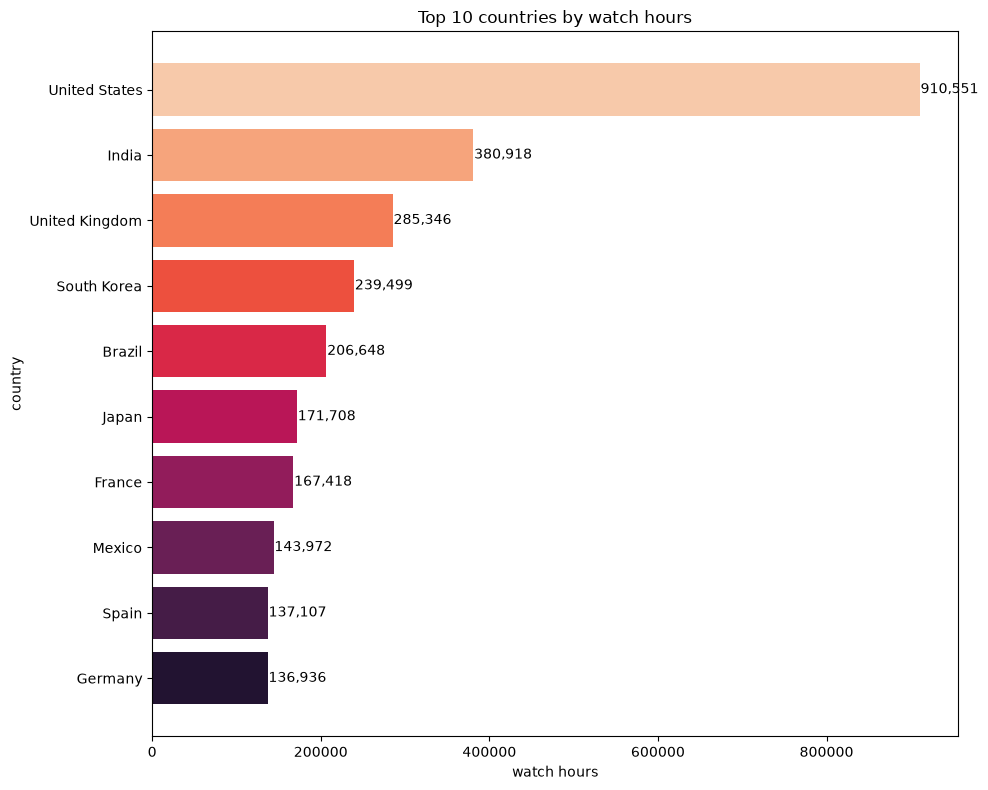

country
Germany           136936.378333
Spain             137107.413333
Mexico            143971.786667
France            167418.188333
Japan             171707.983333
Brazil            206648.200000
South Korea       239498.930000
United Kingdom    285346.350000
India             380917.681667
United States     910551.198333
Name: watch_duration_min, dtype: float64


In [ ]:
countries_data = watch_history.merge(subscribers[['subscriber_id','country']], 
                                     on='subscriber_id',
                                     how='left')#Join watch_history & subscribers to get the countries
countries_watch_hours = countries_data.groupby('country')['watch_duration_min'].sum()/60#Add all watch minutes in each country and convert them into hours.
countries_watch_hours = countries_watch_hours.sort_values(ascending=False).head(10)#sort values and display top 10
top10 = countries_watch_hours.sort_values()

fig,ax = plt.subplots(figsize=(10,8))
colors = sns.color_palette('rocket',len(countries_watch_hours))

bars = ax.barh(                #plot a horizontal bar chart
    top10.index,
    top10.values,
    color=colors
)

ax.set_title('Top 10 countries by watch hours')
plt.xlabel('watch hours')
plt.ylabel('country')
# Add value labels
for bar in bars:                #add values to the right of the bar
    ax.text(
        bar.get_width() + 1000,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():,.0f}',
        va='center'
    )
plt.tight_layout()
fig.savefig('../reports/chart5_top_10_countries_by_watch_hours.png', dpi=150)  # saving the chart in reports folder
plt.show()

print(top10)

**Observation:** The United States dominates with roughly 910,000 watch hours - 
more than double the second-largest market, India (~381,000). The UK, South Korea, 
and Brazil round out the top five, each contributing 200,000-285,000 hours. This 
concentration means StreamFlix's engagement is heavily US-weighted; while India and 
South Korea being in the top tier is a positive sign for international growth, the 
gap between the US and everyone else suggests international markets are still an 
underdeveloped opportunity relative to a platform aiming for global scale.

## Chart 6 - Subscriber plan distribution 

Why subscriber plan distribution :
* To find out which plan contribute the most in the revenue.
* To increase the capacity of the most contributed plan.
* The plan mix (Basic with Ads / Standard / Premium) directly 
determines revenue per subscriber

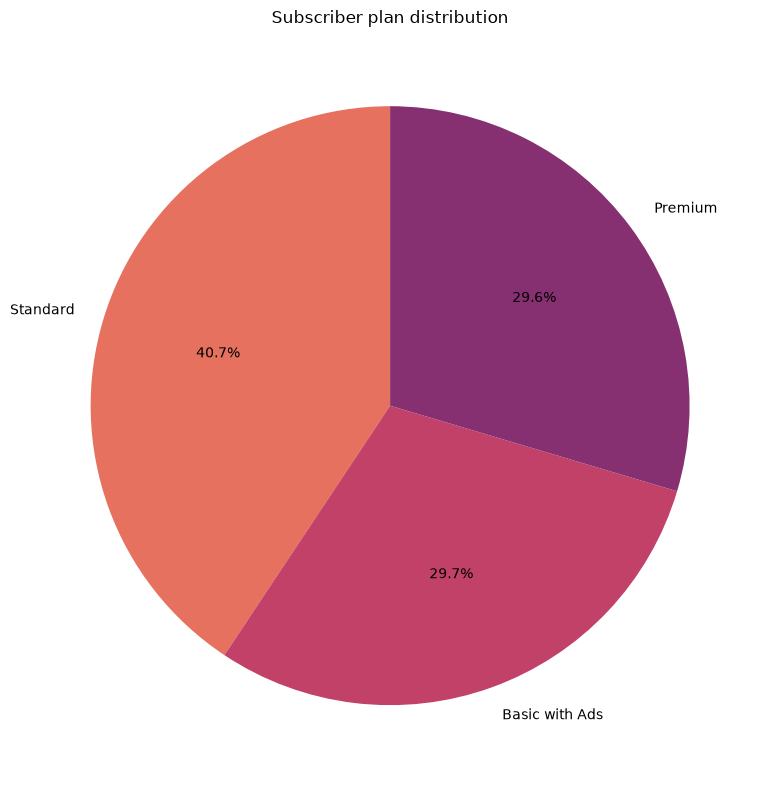

plan_type
Standard          6100
Basic with Ads    4458
Premium           4442
Name: count, dtype: int64


In [ ]:
subscriber_plan_distribution = subscribers['plan_type'].value_counts()#count the values of each type

fig,ax = plt.subplots(figsize=(8,8))
colors=sns.color_palette('flare',len(subscriber_plan_distribution))

ax.pie(                             #plot a pie chart
    subscriber_plan_distribution,
    labels=subscriber_plan_distribution.index,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
)

ax.set_title('Subscriber plan distribution')
plt.tight_layout()
fig.savefig('../reports/chart6_top_10_subscriber_plan_distribution.png', dpi=150)  # saving the chart in reports folder
plt.show()

print(subscriber_plan_distribution)


**Observation:** Standard is the most popular plan with 6,100 subscribers (40.7%), 
while Basic with Ads (4,458, 29.7%) and Premium (4,442, 29.6%) are nearly tied for 
second. The near-even split between the cheapest and most expensive tiers is notable 
- it suggests StreamFlix has a genuinely price-sensitive segment (Basic with Ads) 
almost as large as its premium segment, which matters for how aggressively price 
increases or ad-tier changes could be tested without a mass downgrade risk.

## Chart 7 - Device usage 

Why device usage :
* To identify which device is preffered by the audience to watch.
* knowing which devices dominate viewing tells product and 
engineering teams where to prioritize app performance, UI investment, and testing. 


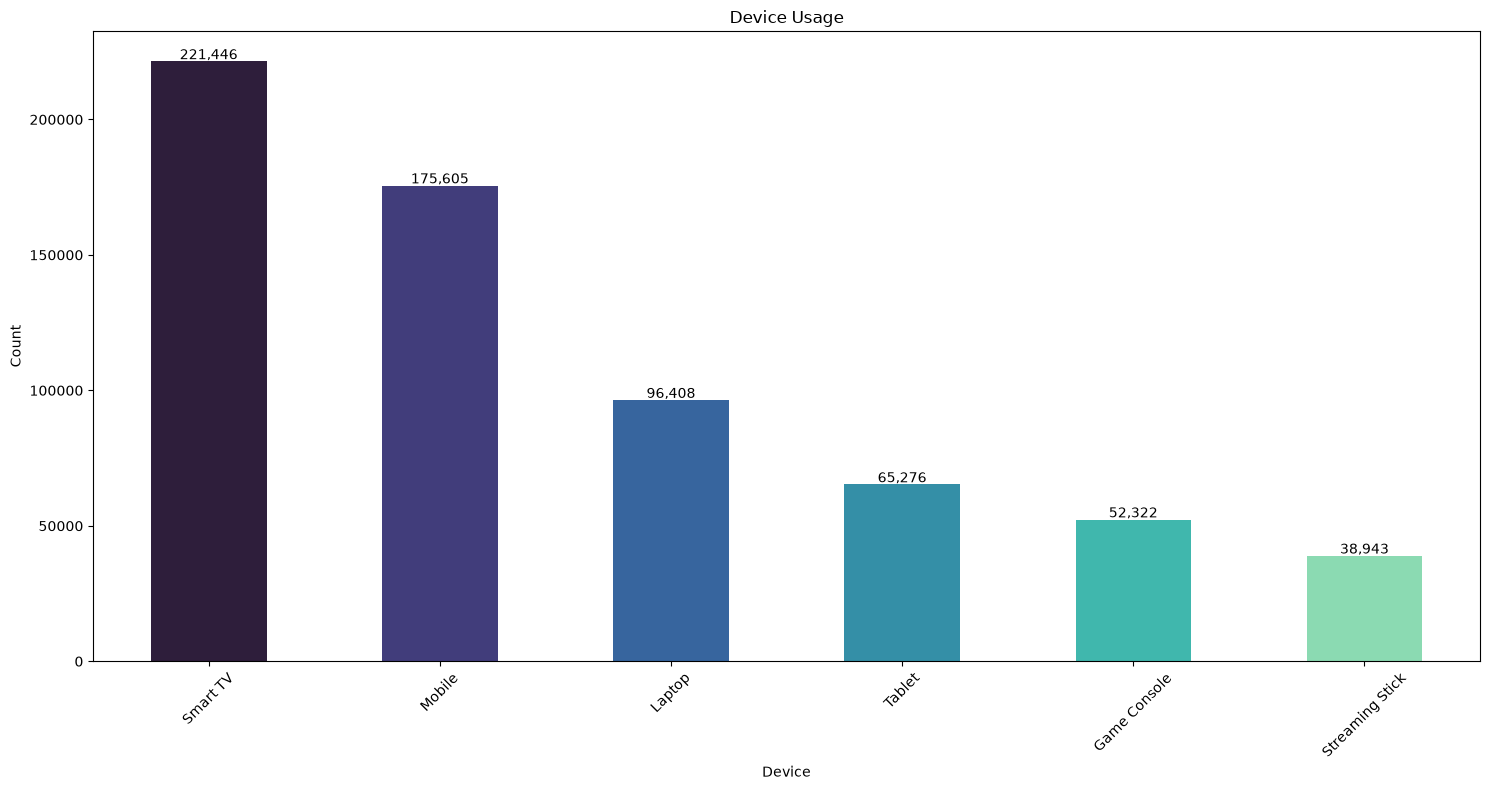

device
Smart TV           221446
Mobile             175605
Laptop              96408
Tablet              65276
Game Console        52322
Streaming Stick     38943
Name: count, dtype: int64


In [ ]:
device_usage = watch_history['device'].value_counts()#count the values of each device

fig, ax = plt.subplots(figsize=(15,8))

colors = sns.color_palette('mako', n_colors=len(device_usage))
device_usage.plot(ax=ax, kind='bar', color=colors)#plot a bar chart
ax.tick_params(axis='x', rotation=45)

plt.title('Device Usage')
plt.xlabel('Device')
plt.ylabel('Count')
for i, v in enumerate(device_usage.values):     #add labels on top of each bar
    plt.text(i, v + 800, f'{v:,}', ha='center')
plt.tight_layout()
plt.savefig('../reports/chart7_device_usage.png', dpi=150)#saving the chart in reports folder
plt.show()

print(device_usage)

**Observation:** Smart TV is the dominant viewing device with 221,446 sessions 
(34%), followed by Mobile (175,605, 27%). Together, Smart TV and Mobile account for 
over 60% of all viewing - Laptop, Tablet, Game Console, and Streaming Stick make up 
the remainder in a long tail. This confirms the living-room and on-the-go experiences 
are what most subscribers actually use day to day, so any UX or performance issue on 
Smart TV or Mobile apps has outsized impact compared to the same issue on, say, Game 
Console.

## Chart 8 - Age distribution of subscribers 

Why age distribution of subscribers :
* Understanding the age spread of the subscriber base informs 
content acquisition (e.g. Kids & Family vs. mature content), marketing targeting, and 
whether specific age segments are worth a dedicated retention strategy.


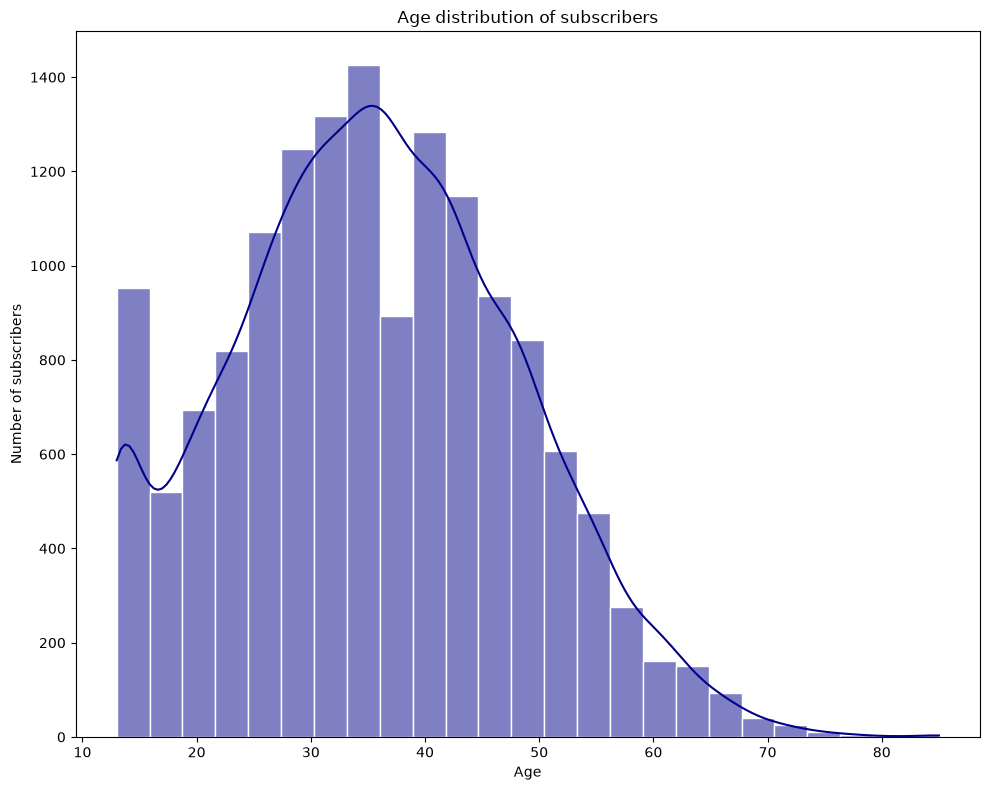

age
13    696
37    501
35    496
36    472
32    470
     ... 
75      2
81      1
84      1
79      1
78      1
Name: count, Length: 70, dtype: int64


In [ ]:
fig, ax = plt.subplots(figsize=(10, 8))

sns.histplot(                               #Directly plotting a histogram for age count, it will show the values of each age
    subscribers['age'],
    bins=25,
    kde=True,
    color="darkblue",
    edgecolor='white',
    ax=ax
)

ax.set_title('Age distribution of subscribers')
ax.set_xlabel('Age')
ax.set_ylabel('Number of subscribers')

plt.tight_layout()
fig.savefig('../reports/chart8_age_distribution_of_subscribers.png', dpi=150)
plt.show()

print(subscribers['age'].value_counts())



**Observation:** The subscriber base skews toward working-age adults - the median 
age is 35, with the middle 50% of subscribers (25th-75th percentile) falling between 
27 and 44 years old. The distribution is roughly bell-shaped with a long right tail 
extending to 85, meaning older subscribers exist but are a small minority. This age 
profile suggests content strategy should prioritize what resonates with a 
27-44-year-old core audience, while treating Kids & Family and older-skewing genres 
as secondary rather than central catalogue investments.

## Chart 9 - Completion rate by genre  

Why Completion rate by genre  :
* A genre can have high watch-hours simply because it has a large 
catalogue, but completion rate measures something different - whether people who 
*start* watching actually *finish*. Low completion despite high hours can signal 
padding, weak content, or mismatched viewer expectations.


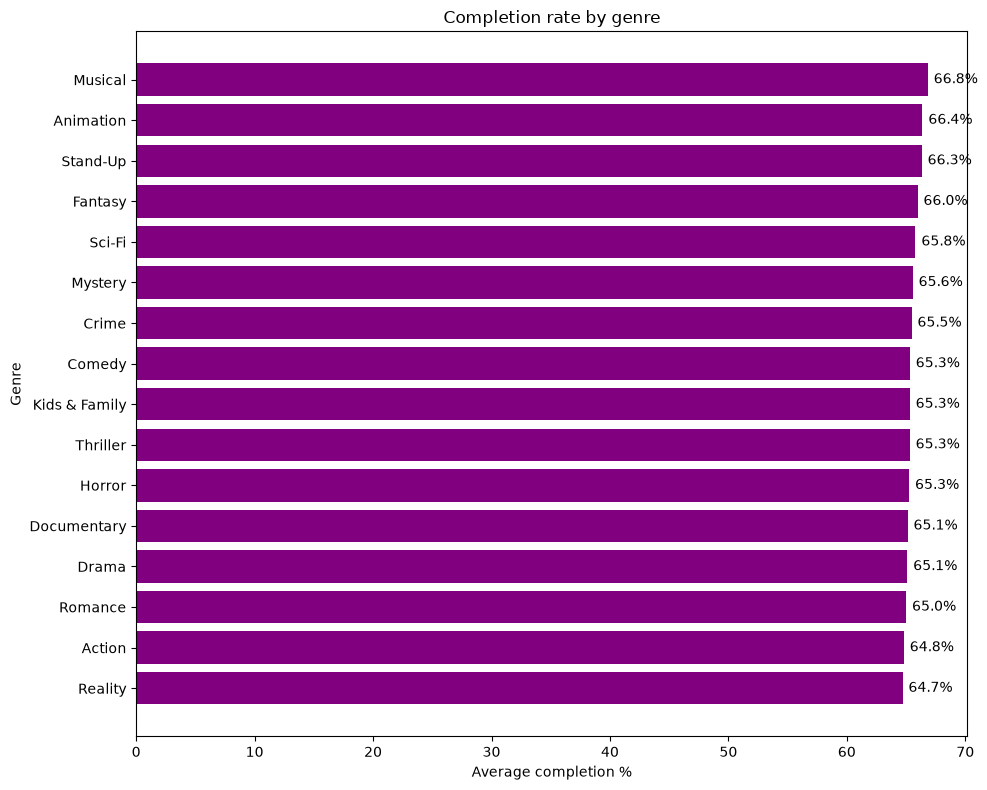

primary_genre
Musical          66.834788
Animation        66.383549
Stand-Up         66.319730
Fantasy          65.968073
Sci-Fi           65.793368
Mystery          65.558980
Crime            65.461294
Comedy           65.316334
Kids & Family    65.309259
Thriller         65.307925
Horror           65.259533
Documentary      65.127758
Drama            65.104168
Romance          65.004707
Action           64.812501
Reality          64.700084
Name: completion_pct, dtype: float64


In [ ]:
# Calculate the average completion percentage for each genre
completion_by_genre = collected_data.groupby('primary_genre')['completion_pct'].mean().sort_values(ascending=False)

fig,ax = plt.subplots(figsize=(10,8))
# Sort from lowest to highest so the horizontal bars appear in ascending order
sorted_completion_by_genre = completion_by_genre.sort_values()

bars = ax.barh(
    sorted_completion_by_genre.index,
    sorted_completion_by_genre.values,
    color='purple'
)
ax.set_title('Completion rate by genre')
plt.xlabel('Average completion %')
plt.ylabel('Genre')
# Display the completion percentage beside each bar
for bar in bars:
    ax.text(
        bar.get_width() + 0.5,
        bar.get_y() + bar.get_height()/2,
        f'{bar.get_width():,.1f}%',
        va='center'
    )
plt.tight_layout()
fig.savefig('../reports/chart9_age_completion_rate_by_genre.png', dpi=150)
plt.show()

print(completion_by_genre)


**Observation:** Completion rates are far more uniform across genres than watch 
hours were - every genre falls in a tight 64.7%-66.8% band, with Musical highest 
(66.8%) and Reality lowest (64.7%). This is a meaningfully different picture than 
Chart 3: Drama leads in total hours but sits mid-pack in completion (65.1%), meaning 
its hours come from volume of viewing, not unusually high per-session engagement. No 
genre stands out as a completion problem - the ~2-point spread across all 16 genres 
suggests completion is driven more by individual title quality than genre category 
itself.

## Chart 10 - Review sentiment breakdown   

Why Review sentiment breakdown   :
* Star ratings (checked separately) capture *how much* people liked 
something, but review sentiment captures the *tone* of what they actually wrote - a 
useful cross-check, and a more nuanced read on subscriber satisfaction.

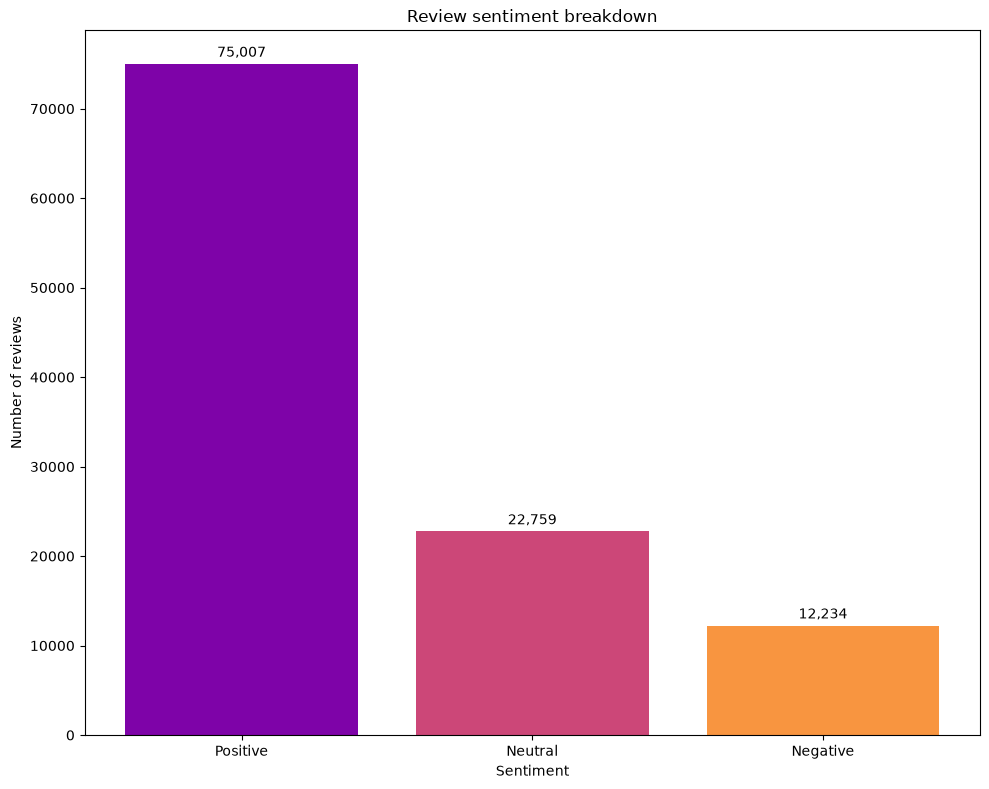

sentiment
Positive    75007
Neutral     22759
Negative    12234
Name: count, dtype: int64

Positive share: 68.2%


In [ ]:
review_counts = reviews['sentiment'].value_counts()#count the values of each sentiment in the reviews

fig,ax = plt.subplots(figsize=(10,8))
colors = sns.color_palette('plasma',len(review_counts))

ax.bar(
    review_counts.index,
    review_counts.values,
    color=colors
)
ax.set_title('Review sentiment breakdown')
plt.xlabel('Sentiment')
plt.ylabel('Number of reviews')
#Add labels on top of each bar
for i, v in enumerate(review_counts.values):
    plt.text(i, v + 800, f'{v:,}', ha='center')
plt.tight_layout()
fig.savefig('../reports/chart10_review_sentiment_breakdown.png', dpi=150)
plt.show()

print(review_counts)
print(f"\nPositive share: {review_counts['Positive'] / review_counts.sum() * 100:.1f}%")


**Observation:** Sentiment is heavily skewed positive - 68.2% of all 110,000 
reviews are Positive (75,007), 20.7% Neutral (22,759), and only 11.1% Negative 
(12,234). This is a healthy overall satisfaction signal, but a ~1-in-9 negative rate 
across 12,000+ reviews is still a substantial volume of dissatisfaction worth 
investigating further - specifically whether negative sentiment clusters around 
particular genres, titles, or devices (a natural follow-up cross-tab for Phase 3 or 
the dashboard, rather than this summary chart).

### Step 3 - Phase 2 Summary

| **Area** | **Key Observation** |
|-----------|---------------------|
| **Viewing Trend** | Viewing volume and total watch hours show strong growth over time. This trend should be compared with subscriber growth to confirm whether it reflects genuine user engagement or is primarily driven by a growing subscriber base. |
| **Top Genres** | Drama, Comedy, and Action contribute the highest watch hours, making them the platform's strongest-performing genres. Musical and Stand-Up generate the lowest watch hours, indicating comparatively lower audience interest. |
| **Geographical Distribution** | The United States contributes the highest watch hours, while India, South Korea, and Brazil also represent significant international audiences, suggesting opportunities for regional content investment. |
| **Subscription Plans** | Subscription plans are fairly balanced across the platform, with the Basic with Ads plan contributing almost as many subscribers as the Premium plan. |
| **Device Usage** | Smart TVs and Mobile devices account for more than 60% of all watch sessions, indicating these are the primary platforms used for content consumption. |
| **Content Engagement** | Average completion rates remain relatively consistent across genres (around the mid-60% range), suggesting that viewer completion depends more on individual title quality than on genre alone. |
| **User Sentiment** | Approximately 68% of reviews are positive, indicating generally high user satisfaction. However, the 11% negative reviews represent a meaningful volume that should be investigated further to identify recurring issues. |
| **Overall Insight** | The analysis shows a growing platform with strong engagement, dominant genres, diverse international viewership, balanced subscription adoption, and generally positive user feedback. These insights provide the foundation for calculating business KPIs in the next phase. |

### Next Step

**Phase 3 – KPI Calculations**

The next phase will focus on calculating key business metrics, including:

- Active Subscriber Rate
- Churn Rate
- Monthly Recurring Revenue (MRR)
- Average Revenue Per User (ARPU)
- Watchlist Conversion Rate
- Hit Concentration
- Subscriber Retention
- Content Completion Rate
- Viewer Engagement Metrics
- Additional business KPIs required for the project

# -------------------------END OF PHASE 2----------------------------